# Check the demand (v2)

Accumulate the region of the user wishes.

Uses the `UserDispo` file.


The `UsersDispo` file has the same shape as the others, example:

```
6/8/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1784073600 0 0 0
N	YES:Faure
6/8/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1781395200 0 0 0
N	YES:Mattsn
```

But may be full of errors with missing `R` lines ...

In [1]:
%matplotlib widget
from datetime import datetime
import numpy as np
from matplotlib.pyplot import subplots
import pandas as pd
import sys
sys.path.append("/nethome/tofhr/ollivier/IN5/experiments_management/SoftTools/Gantt_Calendars/gantt-schedule/")
import src.libschedule as lg    
from importlib import reload
import seaborn as sns
# sns.set_theme('paper')
sns.set_style('whitegrid')

In [ ]:
# planfile = "/home/ollivier/serhome/IN5/experiments_management/SoftTools/Gantt_Calendars/gantt-schedule/tests/data/userDispo_test.txt"
planfile = "/home/ollivier/Calendars/UsersDispo"  # <-- the usr dispo 

In [46]:
reload(lg)
df = lg.from_user_dispo(planfile, verbose=False, print_info=False).df

In [47]:
dflast = df[df.Start > datetime(2026, 7,20)].copy()
# dflast.head()   

From DF last to total days wishes . The `NO` shuld be the inverse: True everywhere else.
The `YES` stayes the same and add-up.  

## Number of experiment at the given overlapping dates

>[!WARNING]
> the vertical ines do not appears when using the `seabon` layout ! (`paper` I was using here)

In [48]:
# Create a date range for each day in the period
# date_range = pd.date_range(start=dflast['Start'].min(), end=dflast['Finish'].max(), freq='D')
date_range = pd.date_range(start=datetime(2026,7,1), end=datetime(2026,12,1), freq='D')
temp_df = pd.DataFrame(date_range, columns=['Date'])

Create a column superimposing the values of the overlapping experiments.

In [49]:
temp_df['Wishes'] = 0
for _, row in dflast.iterrows():
    mask = (temp_df['Date'] >= row['Start']) & (temp_df['Date'] <= row['Finish'])
    temp_df.loc[mask, 'Wishes'] += row['Wishes']

temp_df['Impossible dates'] = 0
for _, row in dflast.iterrows():
    mask = (temp_df['Date'] >= row['Start']) & (temp_df['Date'] <= row['Finish'])
    temp_df.loc[mask, 'Impossible dates'] += row['Impossible dates']
    

Plots ...

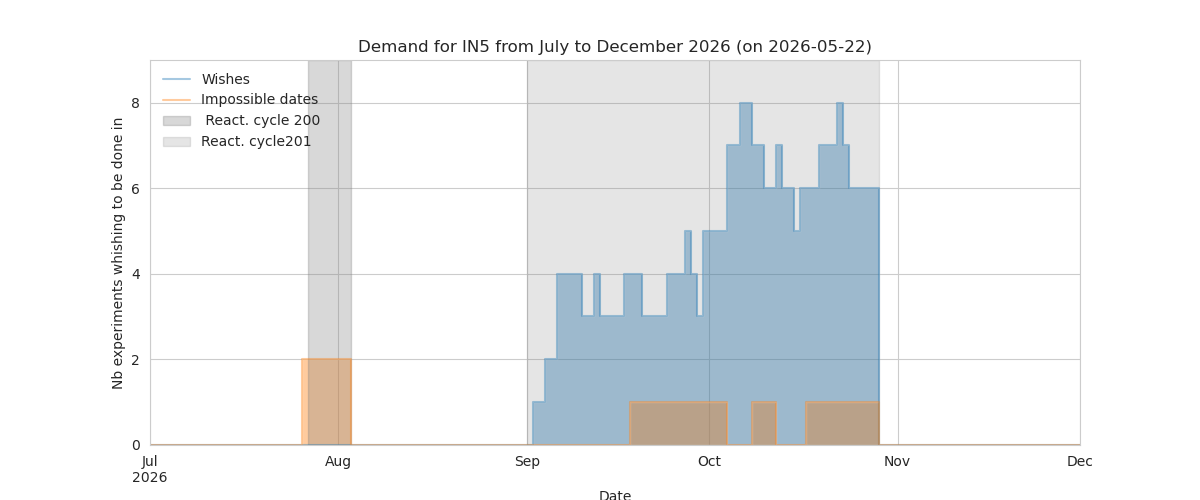

In [51]:
ax = temp_df.plot(x='Date', y='Wishes', kind='line', 
                  drawstyle='steps-pre', 
                  ylabel='Nb experiments whishing to be done in', 
                  legend=False, alpha=0.4,
                  figsize=(12, 5))
temp_df.plot(x='Date', y='Impossible dates', kind='line', drawstyle='steps-pre', ax=ax, alpha=0.4)
ax.fill_between(temp_df['Date'].values, temp_df['Wishes'].values, step='pre', alpha=0.4)
ax.fill_between(temp_df['Date'].values, temp_df['Impossible dates'].values, step='pre', alpha=0.4)
ax.axvspan(datetime(2026,7,27),datetime(2026,8,3), alpha=0.3, color='grey', label=' React. cycle 200')
ax.axvspan(datetime(2026,9,1), datetime(2026,10,29), alpha=0.2, color='grey', label='React. cycle201')
ax.set_xlim(datetime(2026,7,1), datetime(2026,12,1))
ax.set_ylim(-0.01, temp_df['Wishes'].max() + 1)
ax.legend(frameon=False, loc='upper left')
ax.set_title(f"Demand for IN5 from July to December 2026 (on {datetime.today().strftime('%Y-%m-%d')})")

ax.get_figure().savefig(f"Figures/cycles_200-201-demand_plot_on_{datetime.date(datetime.today()).strftime('%Y-%m-%d')}.png", dpi=150)

## Tests 

In [19]:
datetime.date(datetime.today()).strftime("%Y-%m-%d")

'2026-05-22'